In [2]:
import os
import time
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Traditional ML Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_selection import SelectKBest, chi2

# Fix random seed for reproducibility
np.random.seed(42)
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
crack_dir = os.path.join("448", "Cracks")
non_crack_dir = os.path.join("448", "NonCracks")

crack_images = glob.glob(os.path.join(crack_dir, "*.jpg"))
non_crack_images = glob.glob(os.path.join(non_crack_dir, "*.jpg"))

print(f"Total Crack Images found: {len(crack_images)}")
print(f"Total Non-Crack Images found: {len(non_crack_images)}")

# Read one sample image to inspect dimensions & channels
sample_img = cv2.imread(crack_images[0])
print(f"Sample Image Dimensions (H, W, Channels): {sample_img.shape}")
print(f"Data type: {sample_img.dtype}")

Total Crack Images found: 200
Total Non-Crack Images found: 200
Sample Image Dimensions (H, W, Channels): (448, 448, 3)
Data type: uint8


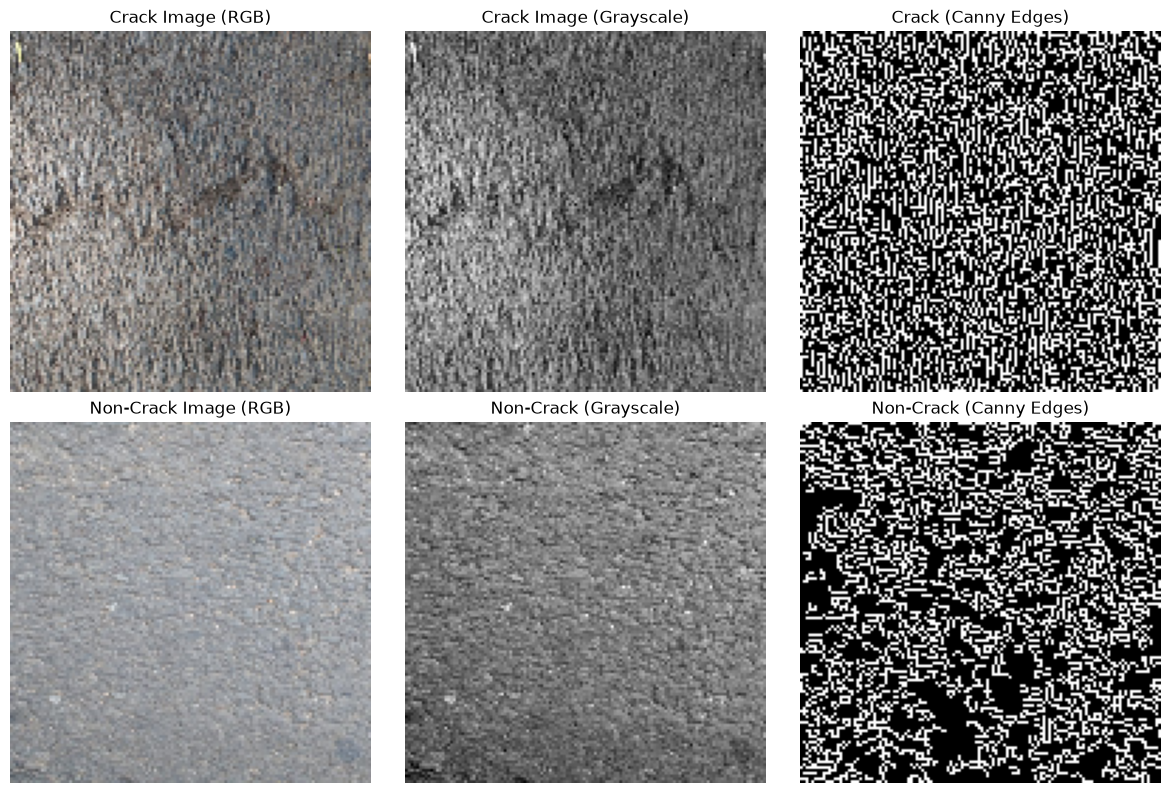

In [4]:
def process_and_display(img_path):
    bgr = cv2.imread(img_path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    resized_rgb = cv2.resize(rgb, (128, 128))
    gray = cv2.cvtColor(resized_rgb, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, threshold1=50, threshold2=150)
    return resized_rgb, gray, edges

crack_rgb, crack_gray, crack_edges = process_and_display(crack_images[0])
non_rgb, non_gray, non_edges = process_and_display(non_crack_images[0])

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Crack
axes[0, 0].imshow(crack_rgb)
axes[0, 0].set_title("Crack Image (RGB)")
axes[0, 0].axis("off")

axes[0, 1].imshow(crack_gray, cmap="gray")
axes[0, 1].set_title("Crack Image (Grayscale)")
axes[0, 1].axis("off")

axes[0, 2].imshow(crack_edges, cmap="gray")
axes[0, 2].set_title("Crack (Canny Edges)")
axes[0, 2].axis("off")

# Non-Crack
axes[1, 0].imshow(non_rgb)
axes[1, 0].set_title("Non-Crack Image (RGB)")
axes[1, 0].axis("off")

axes[1, 1].imshow(non_gray, cmap="gray")
axes[1, 1].set_title("Non-Crack (Grayscale)")
axes[1, 1].axis("off")

axes[1, 2].imshow(non_edges, cmap="gray")
axes[1, 2].set_title("Non-Crack (Canny Edges)")
axes[1, 2].axis("off")

plt.tight_layout()
plt.savefig("canny_edge_visualization.png", dpi=150)
plt.show()

In [5]:
def extract_image_features(image_path, label, target_size=(128, 128)):
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    img_resized = cv2.resize(img, target_size)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    total_pixels = gray.size
    
    # 1. NumPy intensity statistics
    mean_val = np.mean(gray)
    contrast_val = np.std(gray)
    median_val = np.median(gray)
    
    # 2. Dark and Bright pixel ratios
    dark_ratio = np.sum(gray < 80) / total_pixels
    bright_ratio = np.sum(gray > 180) / total_pixels
    
    # 3. OpenCV Canny edge features
    edges = cv2.Canny(gray, threshold1=50, threshold2=150)
    edge_count = np.count_nonzero(edges)
    edge_density = edge_count / total_pixels
    
    return {
        "filename": os.path.basename(image_path),
        "mean_brightness": mean_val,
        "contrast": contrast_val,
        "median_intensity": median_val,
        "dark_pixel_ratio": dark_ratio,
        "bright_pixel_ratio": bright_ratio,
        "edge_count": edge_count,
        "edge_density": edge_density,
        "label": label  # 1 = Crack, 0 = NonCrack
    }

feature_rows = []
for p in crack_images:
    feat = extract_image_features(p, label=1)
    if feat:
        feature_rows.append(feat)

for p in non_crack_images:
    feat = extract_image_features(p, label=0)
    if feat:
        feature_rows.append(feat)

image_features_df = pd.DataFrame(feature_rows)

# Save the deliverable CSV
image_features_df.to_csv("extracted_image_features.csv", index=False)
print(f"Extracted features for {len(image_features_df)} images.")
print(image_features_df.head())

Extracted features for 400 images.
                                     filename  mean_brightness   contrast  \
0  IMG_20180513_164959951_HDR resized_448.jpg       122.263977  33.070752   
1  IMG_20180513_165129852_HDR resized_448.jpg       131.565186  25.482184   
2  IMG_20180513_165150613_HDR resized_448.jpg       121.076355  31.130490   
3  IMG_20180513_165345878_HDR resized_448.jpg       130.309143  27.282676   
4  IMG_20180513_165349788_HDR resized_448.jpg       130.993286  27.639562   

   median_intensity  dark_pixel_ratio  bright_pixel_ratio  edge_count  \
0             121.0          0.094849            0.049561        6009   
1             133.0          0.028320            0.024658        5915   
2             120.0          0.080994            0.042969        5695   
3             131.0          0.034912            0.027954        6078   
4             132.0          0.035461            0.030518        5919   

   edge_density  label  
0      0.366760      1  
1      0.3610

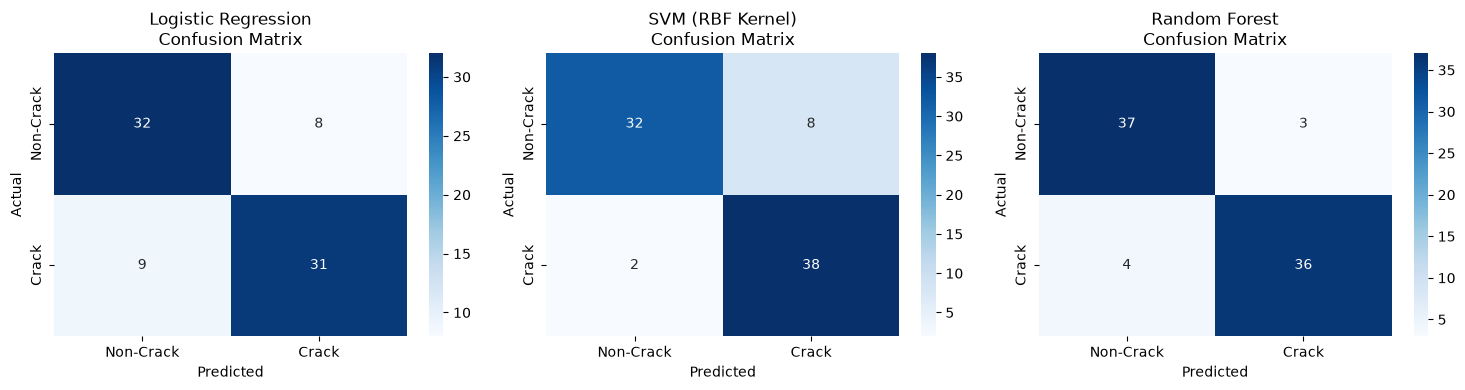


--- Part A: Image Classification Results ---
              Model  Accuracy  Precision  Recall  F1-Score  Train Time (s)  Prediction Time (s)
Logistic Regression    0.7875     0.7949   0.775    0.7848         0.00983              0.00022
   SVM (RBF Kernel)    0.8750     0.8261   0.950    0.8837         0.00306              0.00110
      Random Forest    0.9125     0.9231   0.900    0.9114         0.10464              0.00564


In [6]:
#PART A

feature_cols = [
    "mean_brightness", "contrast", "median_intensity",
    "dark_pixel_ratio", "bright_pixel_ratio", "edge_count", "edge_density"
]

X_img = image_features_df[feature_cols].values
y_img = image_features_df["label"].values

# 80-20 Train-Test Split (Stratified)
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_img, y_img, test_size=0.20, random_state=42, stratify=y_img
)

# Standardize features
scaler_img = StandardScaler()
X_train_img_scaled = scaler_img.fit_transform(X_train_img)
X_test_img_scaled = scaler_img.transform(X_test_img)

image_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

img_results = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, clf) in enumerate(image_models.items()):
    t_start = time.time()
    clf.fit(X_train_img_scaled, y_train_img)
    t_train = time.time() - t_start
    
    t_start = time.time()
    y_pred = clf.predict(X_test_img_scaled)
    t_pred = time.time() - t_start
    
    acc = accuracy_score(y_test_img, y_pred)
    prec = precision_score(y_test_img, y_pred)
    rec = recall_score(y_test_img, y_pred)
    f1 = f1_score(y_test_img, y_pred)
    
    img_results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "Train Time (s)": round(t_train, 5),
        "Prediction Time (s)": round(t_pred, 5)
    })
    
    cm = confusion_matrix(y_test_img, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Non-Crack', 'Crack'], yticklabels=['Non-Crack', 'Crack'])
    axes[idx].set_title(f"{name}\nConfusion Matrix")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("image_confusion_matrices.png", dpi=150)
plt.show()

img_results_df = pd.DataFrame(img_results)
print("\n--- Part A: Image Classification Results ---")
print(img_results_df.to_string(index=False))

Dataset Shape: (5172, 3002)
Ham (0): 3672 (71.00%)
Spam (1): 1500 (29.00%)


C:\Users\Akanksha\AppData\Local\Temp\ipykernel_37444\2155722402.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Ham (0)', 'Spam (1)'], y=[label_counts[0], label_counts[1]], palette='viridis')


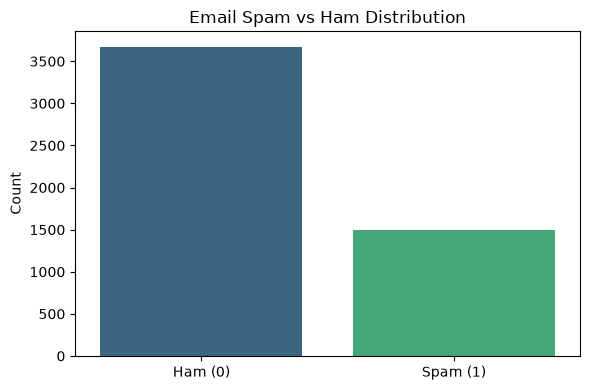

In [7]:
#PART B

emails_df = pd.read_csv("emails.csv")
print(f"Dataset Shape: {emails_df.shape}")

label_counts = emails_df["Prediction"].value_counts()
print(f"Ham (0): {label_counts[0]} ({label_counts[0]/len(emails_df)*100:.2f}%)")
print(f"Spam (1): {label_counts[1]} ({label_counts[1]/len(emails_df)*100:.2f}%)")

plt.figure(figsize=(6, 4))
sns.barplot(x=['Ham (0)', 'Spam (1)'], y=[label_counts[0], label_counts[1]], palette='viridis')
plt.title("Email Spam vs Ham Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("email_class_distribution.png", dpi=150)
plt.show()

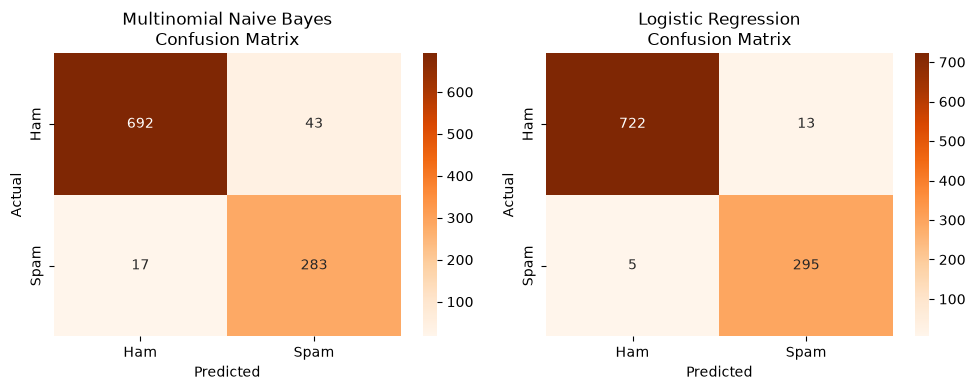


--- Part B: Spam Classification Results ---
                  Model  Features  Accuracy  Precision  Recall  F1-Score  Train Time (s)  Prediction Time (s)
Multinomial Naive Bayes      3000    0.9420     0.8681  0.9433    0.9042         0.38398              0.02408
    Logistic Regression      3000    0.9826     0.9578  0.9833    0.9704         6.83779              0.02132


In [8]:
# Drop non-feature columns
X_text = emails_df.drop(columns=["Email No.", "Prediction"]).values
y_text = emails_df["Prediction"].values
num_features = X_text.shape[1]

# 80-20 Train-Test Split
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y_text, test_size=0.20, random_state=42, stratify=y_text
)

text_models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

text_results = []
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for idx, (name, clf) in enumerate(text_models.items()):
    t_start = time.time()
    clf.fit(X_train_text, y_train_text)
    t_train = time.time() - t_start
    
    t_start = time.time()
    y_pred = clf.predict(X_test_text)
    t_pred = time.time() - t_start
    
    acc = accuracy_score(y_test_text, y_pred)
    prec = precision_score(y_test_text, y_pred)
    rec = recall_score(y_test_text, y_pred)
    f1 = f1_score(y_test_text, y_pred)
    
    text_results.append({
        "Model": name,
        "Features": num_features,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "Train Time (s)": round(t_train, 5),
        "Prediction Time (s)": round(t_pred, 5)
    })
    
    cm = confusion_matrix(y_test_text, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[idx],
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    axes[idx].set_title(f"{name}\nConfusion Matrix")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("text_confusion_matrices.png", dpi=150)
plt.show()

text_results_df = pd.DataFrame(text_results)
print("\n--- Part B: Spam Classification Results ---")
print(text_results_df.to_string(index=False))

In [9]:
#PART C
# Reduce 3,000 words to top 500 most informative words using Chi-2
k_features = 500
selector = SelectKBest(score_func=chi2, k=k_features)

X_train_reduced = selector.fit_transform(X_train_text, y_train_text)
X_test_reduced = selector.transform(X_test_text)

nb_improved = MultinomialNB()

t_start = time.time()
nb_improved.fit(X_train_reduced, y_train_text)
t_train_improved = time.time() - t_start

t_start = time.time()
y_pred_improved = nb_improved.predict(X_test_reduced)
t_pred_improved = time.time() - t_start

acc_imp = accuracy_score(y_test_text, y_pred_improved)
prec_imp = precision_score(y_test_text, y_pred_improved)
rec_imp = recall_score(y_test_text, y_pred_improved)
f1_imp = f1_score(y_test_text, y_pred_improved)

# Comparison Table
comparison_df = pd.DataFrame([
    {
        "Representation": "Original (All 3000 Words)",
        "Feature Count": 3000,
        "Accuracy": text_results_df.loc[text_results_df['Model'] == 'Multinomial Naive Bayes', 'Accuracy'].values[0],
        "F1-Score": text_results_df.loc[text_results_df['Model'] == 'Multinomial Naive Bayes', 'F1-Score'].values[0],
        "Train Time (s)": text_results_df.loc[text_results_df['Model'] == 'Multinomial Naive Bayes', 'Train Time (s)'].values[0],
        "Prediction Time (s)": text_results_df.loc[text_results_df['Model'] == 'Multinomial Naive Bayes', 'Prediction Time (s)'].values[0]
    },
    {
        "Representation": "Improved (Top 500 Chi-2 Words)",
        "Feature Count": k_features,
        "Accuracy": round(acc_imp, 4),
        "F1-Score": round(f1_imp, 4),
        "Train Time (s)": round(t_train_improved, 5),
        "Prediction Time (s)": round(t_pred_improved, 5)
    }
])

print("\n--- Part C: Representation Comparison ---")
print(comparison_df.to_string(index=False))

# Show top 10 most discriminative words chosen by Chi-2
feature_names = emails_df.drop(columns=["Email No.", "Prediction"]).columns
selected_mask = selector.get_support()
top_words = feature_names[selected_mask]
scores = selector.scores_[selected_mask]
top_words_df = pd.DataFrame({"Word": top_words, "Chi2_Score": scores}).sort_values(by="Chi2_Score", ascending=False).head(10)

print("\nTop 10 Most Discriminative Spam Words:")
print(top_words_df.to_string(index=False))


--- Part C: Representation Comparison ---
                Representation  Feature Count  Accuracy  F1-Score  Train Time (s)  Prediction Time (s)
     Original (All 3000 Words)           3000    0.9420    0.9042         0.38398              0.02408
Improved (Top 500 Chi-2 Words)            500    0.9304    0.8857         0.00770              0.00425

Top 10 Most Discriminative Spam Words:
Word   Chi2_Score
   i 15292.820504
   s  7046.669041
   r  6422.022288
   a  5600.862339
   o  5059.549854
   p  4569.769406
   n  4425.318460
   e  3851.178539
   t  3599.776117
   g  3239.582284
